# Transfer Learning mit PyTorch: Zoobot (ConvNeXt-Nano)

In diesem Notebook nutzen wir nativ **PyTorch** und die Bibliothek **timm**, um das offiziell vortrainierte Zoobot-Modell `ConvNeXt-Nano` auf den Galaxy10 DECals Datensatz feinzutunen.

Wir nutzen weiterhin unsere `data.py` für die einheitliche Erstellung der K-Fold-Splits. Die Keras-Skripte (`train.py`, `generator.py`) werden hier durch reine PyTorch-Klassen und Trainingsschleifen ersetzt.

In [36]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
import timm

# Import aus deiner bestehenden Daten-Pipeline
from data import load_data, prepare_splits, NUM_CLASSES, LABEL_DICT

# PyTorch Device Setup (GPU wenn möglich, sonst CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Verwendetes Device: {device}")

Verwendetes Device: cuda


In [37]:
# --- Experiment-Schalter ---
USE_KFOLD   = False   # True = 5-fache Kreuzvalidierung | False = einfacher Train/Val-Split
LOAD_MODELS = False   # True = gespeicherte Checkpoints laden statt neu trainieren

# --- Datenpfade ---
DATA_PATH = './../data/Galaxy10_DECals.h5'
LOGS_DIR  = './../logs/'

# --- Hyperparameter ---
BATCH_SIZE     = 32
EPOCHS         = 100
LEARNING_RATE  = 1e-4
K_FOLDS        = 5      # nur relevant wenn USE_KFOLD = True
RANDOM_STATE   = 42

In [38]:
print("Lade Rohbilder in den RAM...")
images_raw, labels = load_data(DATA_PATH)

print("Erstelle Train/Val Folds und Test-Split...")
folds, X_test, y_test = prepare_splits(
    labels,
    use_kfold    = USE_KFOLD,
    k            = K_FOLDS,
    random_state = RANDOM_STATE,
)

print(f"Anzahl Folds: {len(folds)}")
print(f"Test-Set Größe: {len(X_test)}")

Lade Rohbilder in den RAM...
Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)
Erstelle Train/Val Folds und Test-Split...

Split-Modus : Einfacher Train/Val-Split
Train + Val : 14,188 Samples
Test        : 3,548 Samples
  Train 11,350 | Val 2,838
Anzahl Folds: 1
Test-Set Größe: 3548


In [39]:
class GalaxyDataset(Dataset):
    """
    PyTorch Dataset, das Bilder aus dem NumPy RAM-Array holt,
    die Channel-Reihenfolge anpasst (H,W,C -> C,H,W) und Augmentierungen anwendet.
    """
    def __init__(self, images_array, labels_array, indices, transform=None):
        self.images = images_array
        self.labels = labels_array
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Absoluten Index holen
        real_idx = self.indices[idx]
        
        # Bild (uint8) und Label laden
        img_np = self.images[real_idx]
        label = self.labels[real_idx]
        
        # Keras nutzt (H, W, Channels), PyTorch nutzt (Channels, H, W)
        img_np = np.transpose(img_np, (2, 0, 1))
        
        # Konvertiere zu PyTorch Tensor und normiere auf [0, 1]
        img_tensor = torch.tensor(img_np, dtype=torch.float32) / 255.0
        
        # Wende Data Augmentation an (falls vorhanden)
        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        label_tensor = torch.tensor(label, dtype=torch.long)
        return img_tensor, label_tensor

# Data Augmentation (ähnlich zu deinen Keras-Layern)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
])
# Test/Val braucht keine Augmentierung
val_transforms = None

In [40]:
class ZoobotConvNeXtNano(nn.Module):
    def __init__(self, num_classes=10, freeze_backbone=True):
        super().__init__()
        
        # 1. Headless ConvNeXt-Nano von HuggingFace laden
        # num_classes=0 entfernt den alten Klassifikations-Kopf
        print("Lade Zoobot Base-Model von HuggingFace...")
        self.backbone = timm.create_model('hf_hub:mwalmsley/zoobot-encoder-convnext_nano', pretrained=True, num_classes=0)
        
        # 2. Gewichte einfrieren (Feature Extraction)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
                
        # 3. Custom Head für Galaxy10 aufbauen
        # backbone.num_features gibt uns dynamisch die Feature-Vektor-Länge (meist 640 bei Nano)
        in_features = self.backbone.num_features 
        
        # self.head = nn.Sequential(
        #     nn.Linear(in_features, num_classes)
        # )

        self.head = nn.Sequential(
            nn.Linear(in_features, 256),  
            nn.BatchNorm1d(256),          
            nn.ReLU(),                    
            nn.Dropout(0.5),              
            nn.Linear(256, num_classes)   
        )
        
    def forward(self, x):
        features = self.backbone(x)
        output = self.head(features)
        return output

In [41]:
def train_fold_pytorch(fold_idx, train_idx, val_idx, images_raw, labels, epochs=20, batch_size=32, patience=5):
    """
    Trainiert ein Modell auf einem spezifischen Fold.
    """
    print(f"\n{'=' * 50}\nStarte Training für Fold {fold_idx + 1}\n{'=' * 50}")
    
    # DataLoader erstellen
    train_dataset = GalaxyDataset(images_raw, labels, train_idx, transform=train_transforms)
    val_dataset = GalaxyDataset(images_raw, labels, val_idx, transform=val_transforms)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # Modell, Loss und Optimizer initialisieren
    model = ZoobotConvNeXtNano(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=1e-4) # Nur den Kopf trainieren
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    writer = SummaryWriter(log_dir=f"{LOGS_DIR}/zoobot_experiment_morecomplexhead/fold_{fold_idx + 1}")

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # --- VALIDATION ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, targets in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                inputs, targets = inputs.to(device), targets.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()
                
        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val
        
        # --- TENSORBOARD LOGGING ---
        # Schreibe die Werte für diese Epoche in TensorBoard
        writer.add_scalar('Loss/Train', epoch_train_loss, epoch)
        writer.add_scalar('Loss/Validation', epoch_val_loss, epoch)
        writer.add_scalar('Accuracy/Train', epoch_train_acc, epoch)
        writer.add_scalar('Accuracy/Validation', epoch_val_acc, epoch)
        writer.add_scalar('Learning Rate', optimizer.param_groups[0]['lr'], epoch)

        # Scheduler Step
        scheduler.step(epoch_val_loss)
        
        # Speichern für History
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
        
        # Early Stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"  -> Neues bestes Modell gespeichert! (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly Stopping ausgelöst nach {epoch+1} Epochen!")
                break
                
    # Bestes Modell wiederherstellen
    writer.close()
    model.load_state_dict(best_model_weights)
    return model, history

In [42]:
fold_models = []
fold_histories = []

# Iteriere über die Splits aus data.py
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    model, history = train_fold_pytorch(
        fold_idx=fold_idx,
        train_idx=train_idx,
        val_idx=val_idx,
        images_raw=images_raw,
        labels=labels,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        patience=6
    )
    fold_models.append(model)
    fold_histories.append(history)


Starte Training für Fold 1
Lade Zoobot Base-Model von HuggingFace...


Epoch 1/100 [Val]: 100%|██████████| 89/89 [00:06<00:00, 13.28it/s]


Train Loss: 0.7914 | Train Acc: 0.7811 | Val Loss: 0.4647 | Val Acc: 0.8594
  -> Neues bestes Modell gespeichert! (Val Loss: 0.4647)


Epoch 2/100 [Val]: 100%|██████████| 89/89 [00:06<00:00, 13.35it/s]


Train Loss: 0.5014 | Train Acc: 0.8522 | Val Loss: 0.4102 | Val Acc: 0.8739
  -> Neues bestes Modell gespeichert! (Val Loss: 0.4102)


...

Train Loss: 0.3078 | Train Acc: 0.8932 | Val Loss: 0.3383 | Val Acc: 0.8897


Epoch 31/100 [Val]: 100%|██████████| 89/89 [00:06<00:00, 13.32it/s]


Train Loss: 0.3131 | Train Acc: 0.8934 | Val Loss: 0.3401 | Val Acc: 0.8883


Epoch 32/100 [Val]: 100%|██████████| 89/89 [00:06<00:00, 13.32it/s]

Train Loss: 0.3015 | Train Acc: 0.8967 | Val Loss: 0.3427 | Val Acc: 0.8876

Early Stopping ausgelöst nach 32 Epochen!



**************************************************
TEST-EVALUIERUNG
**************************************************
Fold 1 Test Accuracy: 0.8861 (88.61%)

Bestes Modell: Fold 1 mit 88.61% Accuracy


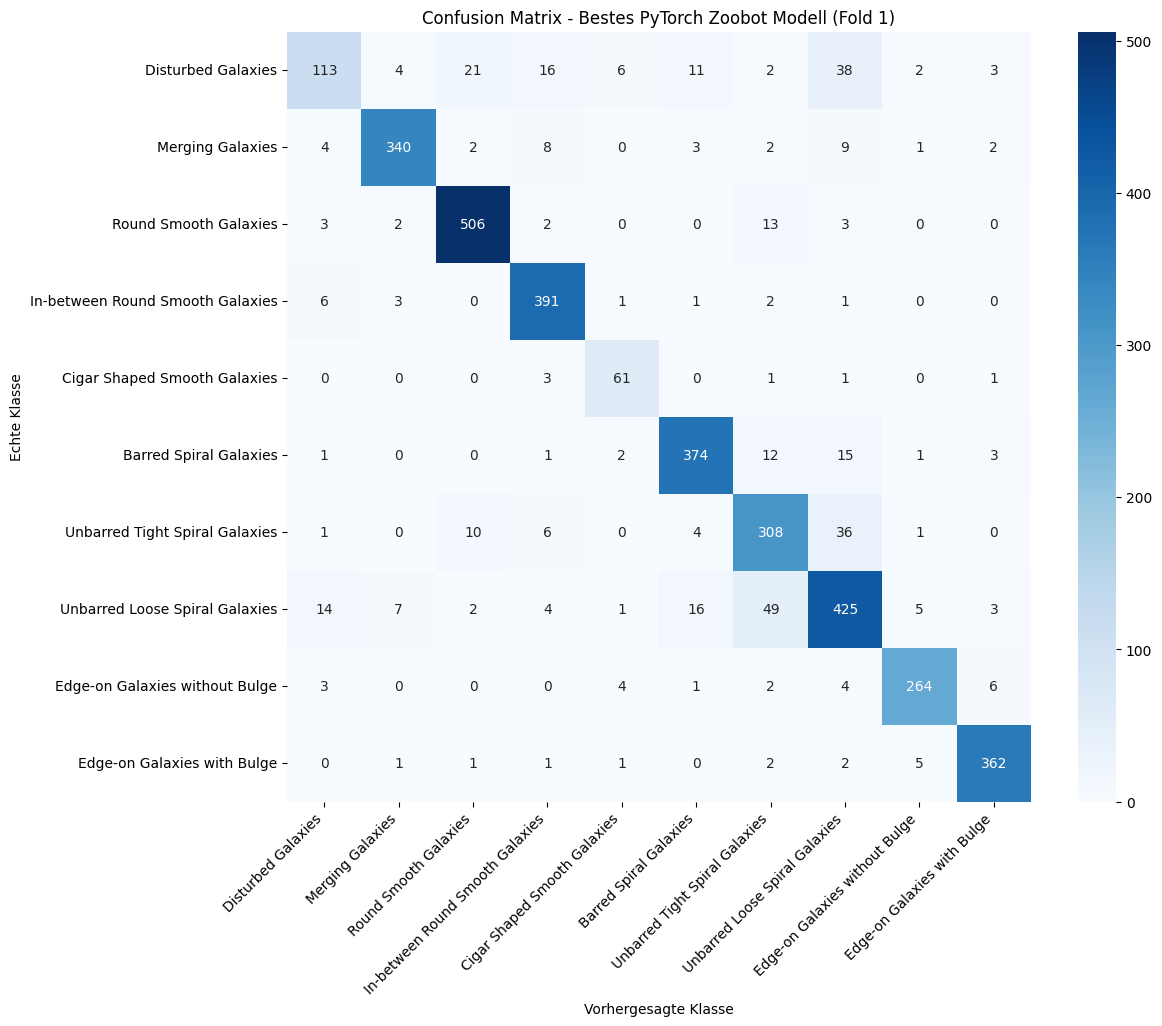

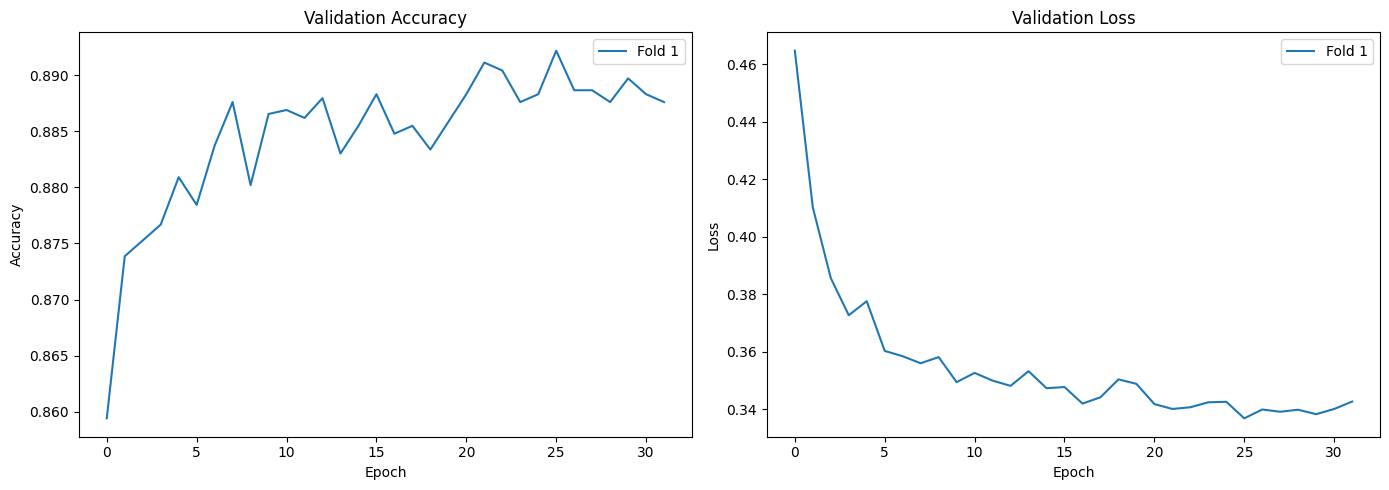

In [43]:
def evaluate_pytorch_model(model, test_idx, images_raw, labels, batch_size=32):
    model.eval()
    test_dataset = GalaxyDataset(images_raw, labels, test_idx, transform=None)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.numpy())
            
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    accuracy = (all_preds == all_targets).mean()
    
    return accuracy, all_preds, all_targets

# Teste alle Folds
test_accuracies = []
best_model_idx = 0
best_acc = 0

print(f"\n{'*' * 50}\nTEST-EVALUIERUNG\n{'*' * 50}")
for i, model in enumerate(fold_models):
    acc, _, _ = evaluate_pytorch_model(model, X_test, images_raw, labels, batch_size=BATCH_SIZE)
    test_accuracies.append(acc)
    print(f"Fold {i+1} Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    if acc > best_acc:
        best_acc = acc
        best_model_idx = i

best_model = fold_models[best_model_idx]
print(f"\nBestes Modell: Fold {best_model_idx+1} mit {best_acc*100:.2f}% Accuracy")

# Confusion Matrix für das beste Modell plotten
_, best_preds, best_targets = evaluate_pytorch_model(best_model, X_test, images_raw, labels, batch_size=BATCH_SIZE)

cm = confusion_matrix(best_targets, best_preds)
class_names = [LABEL_DICT[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - Bestes PyTorch Zoobot Modell (Fold {best_model_idx+1})")
plt.ylabel("Echte Klasse")
plt.xlabel("Vorhergesagte Klasse")
plt.xticks(rotation=45, ha="right")
plt.show()

# Trainingsverlauf plotten
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, history in enumerate(fold_histories):
    axes[0].plot(history['val_acc'], label=f"Fold {i+1}")
    axes[1].plot(history['val_loss'], label=f"Fold {i+1}")

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()